# Phase 2b: remove predicted doublets and recluster PBMC4k

This notebook uses the pre-QC Scrublet decisions saved by `02_eda_clustering.ipynb`, removes only the individually predicted doublets, and reruns scaling, PCA, neighbors, UMAP, Leiden clustering, and marker discovery.

The original Phase 1 and all-cell Phase 2 objects are preserved. A new singlet-only object is written instead of overwriting them.

In [1]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
N_PCS = 10
N_NEIGHBORS = 15
LEIDEN_RESOLUTION = 0.5
N_MARKERS_TO_DISPLAY = 10

ad.settings.allow_write_nullable_strings = True
sc.settings.verbosity = 2
sc.set_figure_params(dpi=110, facecolor="white", frameon=False)
sns.set_theme(style="whitegrid", context="notebook")

## 1. Load normalized expression and reviewed doublet evidence

Normalized expression is reloaded from Phase 1 so PCA is not rerun on the matrix previously scaled with doublets present. Doublet decisions and original Leiden labels come from the completed Phase 2 object.

In [2]:
cwd = Path.cwd().resolve()
candidates = []
for base in (cwd, *cwd.parents):
    candidates.extend(
        (base, base / "PBMC4k", base / "26-the-backpropagators-analysis" / "PBMC4k")
    )

PROJECT = next(
    (
        path
        for path in candidates
        if (path / "data" / "processed" / "pbmc4k_phase2_clustered.h5ad").is_file()
    ),
    None,
)
if PROJECT is None:
    raise FileNotFoundError(
        "Run PBMC4k Notebook 02 through its validation save cell first; expected "
        "PBMC4k/data/processed/pbmc4k_phase2_clustered.h5ad"
    )

PHASE1_INPUT = PROJECT / "data" / "processed" / "pbmc4k_phase1_qc_normalized.h5ad"
VALIDATED_INPUT = PROJECT / "data" / "processed" / "pbmc4k_phase2_clustered.h5ad"
OUTPUT = PROJECT / "data" / "processed" / "pbmc4k_phase2_singlets_clustered.h5ad"
FIGURES = PROJECT / "results" / "figures"
TABLES = PROJECT / "results" / "tables"
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

phase1 = sc.read_h5ad(PHASE1_INPUT)
validated = sc.read_h5ad(VALIDATED_INPUT)

requirements = {
    "matching cells": phase1.obs_names.equals(validated.obs_names),
    "predicted-doublet decisions": "predicted_doublet" in validated.obs,
    "doublet scores": "doublet_score" in validated.obs,
    "original Leiden labels": "leiden" in validated.obs,
    "Phase 1 clustering features": "selected_by_pbmc4k_std" in phase1.var,
    "all-gene normalized expression": phase1.raw is not None,
}
display(pd.Series(requirements, name="available").to_frame())
if not all(requirements.values()):
    raise ValueError("The Phase 1 and validated Phase 2 objects are incompatible or incomplete.")

,available
matching cells,True
predicted-doublet decisions,True
doublet scores,True
original Leiden labels,True
Phase 1 clustering features,True
all-gene normalized expression,True


## 2. Exclude individually predicted doublets

This step does not delete an entire Leiden cluster. It removes each cell for which Scrublet recorded `predicted_doublet = True`, regardless of its original cluster. The source objects remain unchanged on disk.

In [3]:
doublet_decisions = validated.obs[["doublet_score", "predicted_doublet", "leiden"]].copy()
doublet_decisions["leiden"] = doublet_decisions["leiden"].astype(str)

removal_by_cluster = (
    doublet_decisions.groupby("leiden", observed=True)
    .agg(
        starting_cells=("predicted_doublet", "size"),
        predicted_doublets=("predicted_doublet", "sum"),
        median_doublet_score=("doublet_score", "median"),
    )
)
removal_by_cluster["retained_cells"] = (
    removal_by_cluster["starting_cells"] - removal_by_cluster["predicted_doublets"]
)
removal_by_cluster["removed_percent"] = (
    100 * removal_by_cluster["predicted_doublets"] / removal_by_cluster["starting_cells"]
)
removal_by_cluster.to_csv(TABLES / "pbmc4k_phase2b_doublet_removal_by_original_cluster.csv")
display(
    removal_by_cluster.style.format(
        {"median_doublet_score": "{:.3f}", "removed_percent": "{:.1f}%"}
    )
)

keep_mask = ~validated.obs["predicted_doublet"].astype(bool)
singlet_adata = phase1[keep_mask].copy()
singlet_adata.obs["doublet_score"] = validated.obs.loc[
    singlet_adata.obs_names, "doublet_score"
].astype(float)
singlet_adata.obs["predicted_doublet"] = False
singlet_adata.obs["original_leiden"] = pd.Categorical(
    validated.obs.loc[singlet_adata.obs_names, "leiden"].astype(str)
)

filter_summary = pd.Series(
    {
        "starting QC-passing cells": phase1.n_obs,
        "Scrublet-predicted doublets removed": int((~keep_mask).sum()),
        "singlets retained": singlet_adata.n_obs,
        "retained percentage": 100 * singlet_adata.n_obs / phase1.n_obs,
    },
    name="Doublet filtering",
)
display(filter_summary.to_frame())

,starting_cells,predicted_doublets,median_doublet_score,retained_cells,removed_percent
leiden,,,,,
0,864,8,0.034,856,0.9%
1,509,0,0.054,509,0.0%
10,35,13,0.212,22,37.1%
2,162,0,0.042,162,0.0%
3,1050,0,0.044,1050,0.0%
4,569,0,0.042,569,0.0%
5,34,0,0.045,34,0.0%
6,605,11,0.020,594,1.8%
7,44,0,0.084,44,0.0%


,Doublet filtering
starting QC-passing cells,4169.00000
Scrublet-predicted doublets removed,38.00000
singlets retained,4131.00000
retained percentage,99.08851


## 3. Recalculate PCA, neighbors, UMAP, and Leiden

The same 2,000 Phase 1 feature flags, 10 PCs, 15 neighbors, and Leiden resolution 0.5 are reused so the before/after comparison isolates the effect of removing predicted doublets.

In [4]:
feature_mask = singlet_adata.var["selected_by_pbmc4k_std"].astype(bool).to_numpy()
singlet_adata = singlet_adata[:, feature_mask].copy()
singlet_adata.layers["log_normalized"] = singlet_adata.X.copy()

sc.pp.scale(singlet_adata, max_value=10)
n_pcs_available = min(50, singlet_adata.n_obs - 1, singlet_adata.n_vars - 1)
sc.tl.pca(
    singlet_adata,
    n_comps=n_pcs_available,
    svd_solver="arpack",
    random_state=RANDOM_STATE,
)
pcs_used = min(N_PCS, singlet_adata.obsm["X_pca"].shape[1])
sc.pp.neighbors(
    singlet_adata,
    n_neighbors=N_NEIGHBORS,
    n_pcs=pcs_used,
    method="umap",
    random_state=RANDOM_STATE,
)
sc.tl.umap(singlet_adata, random_state=RANDOM_STATE)
sc.tl.leiden(
    singlet_adata,
    resolution=LEIDEN_RESOLUTION,
    key_added="leiden",
    random_state=RANDOM_STATE,
    flavor="igraph",
    n_iterations=2,
    directed=False,
)

print(
    f"Reclustered {singlet_adata.n_obs:,} singlets into "
    f"{singlet_adata.obs['leiden'].nunique()} Leiden clusters."
)

computing PCA


    with n_comps=50


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


    finished (0:00:02)


computing neighbors


...

computing UMAP


    finished (0:00:06)


running Leiden clustering


    finished (0:00:00)


Reclustered 4,131 singlets into 10 Leiden clusters.


## 4. Compare the original and singlet-only clusters

Cluster numbers are arbitrary and can change after reclustering. The contingency table shows where cells from each original cluster were reassigned.

,cells,percent
leiden,,
0,188,4.6%
1,735,17.8%
2,440,10.7%
3,1075,26.0%
4,588,14.2%
5,34,0.8%
6,592,14.3%
7,181,4.4%
8,192,4.6%


singlet_leiden,0,1,2,3,4,5,6,7,8,9
original_leiden,,,,,,,,,,
0,188,668,0,0,0,0,0,0,0,0
1,0,0,438,25,20,0,0,0,26,0
10,0,22,0,0,0,0,0,0,0,0
2,0,0,0,3,0,0,0,0,159,0
3,0,0,2,1045,0,0,0,0,3,0
4,0,0,0,1,564,0,0,0,4,0
5,0,0,0,0,0,34,0,0,0,0
6,0,0,0,1,1,0,592,0,0,0
7,0,44,0,0,0,0,0,0,0,0


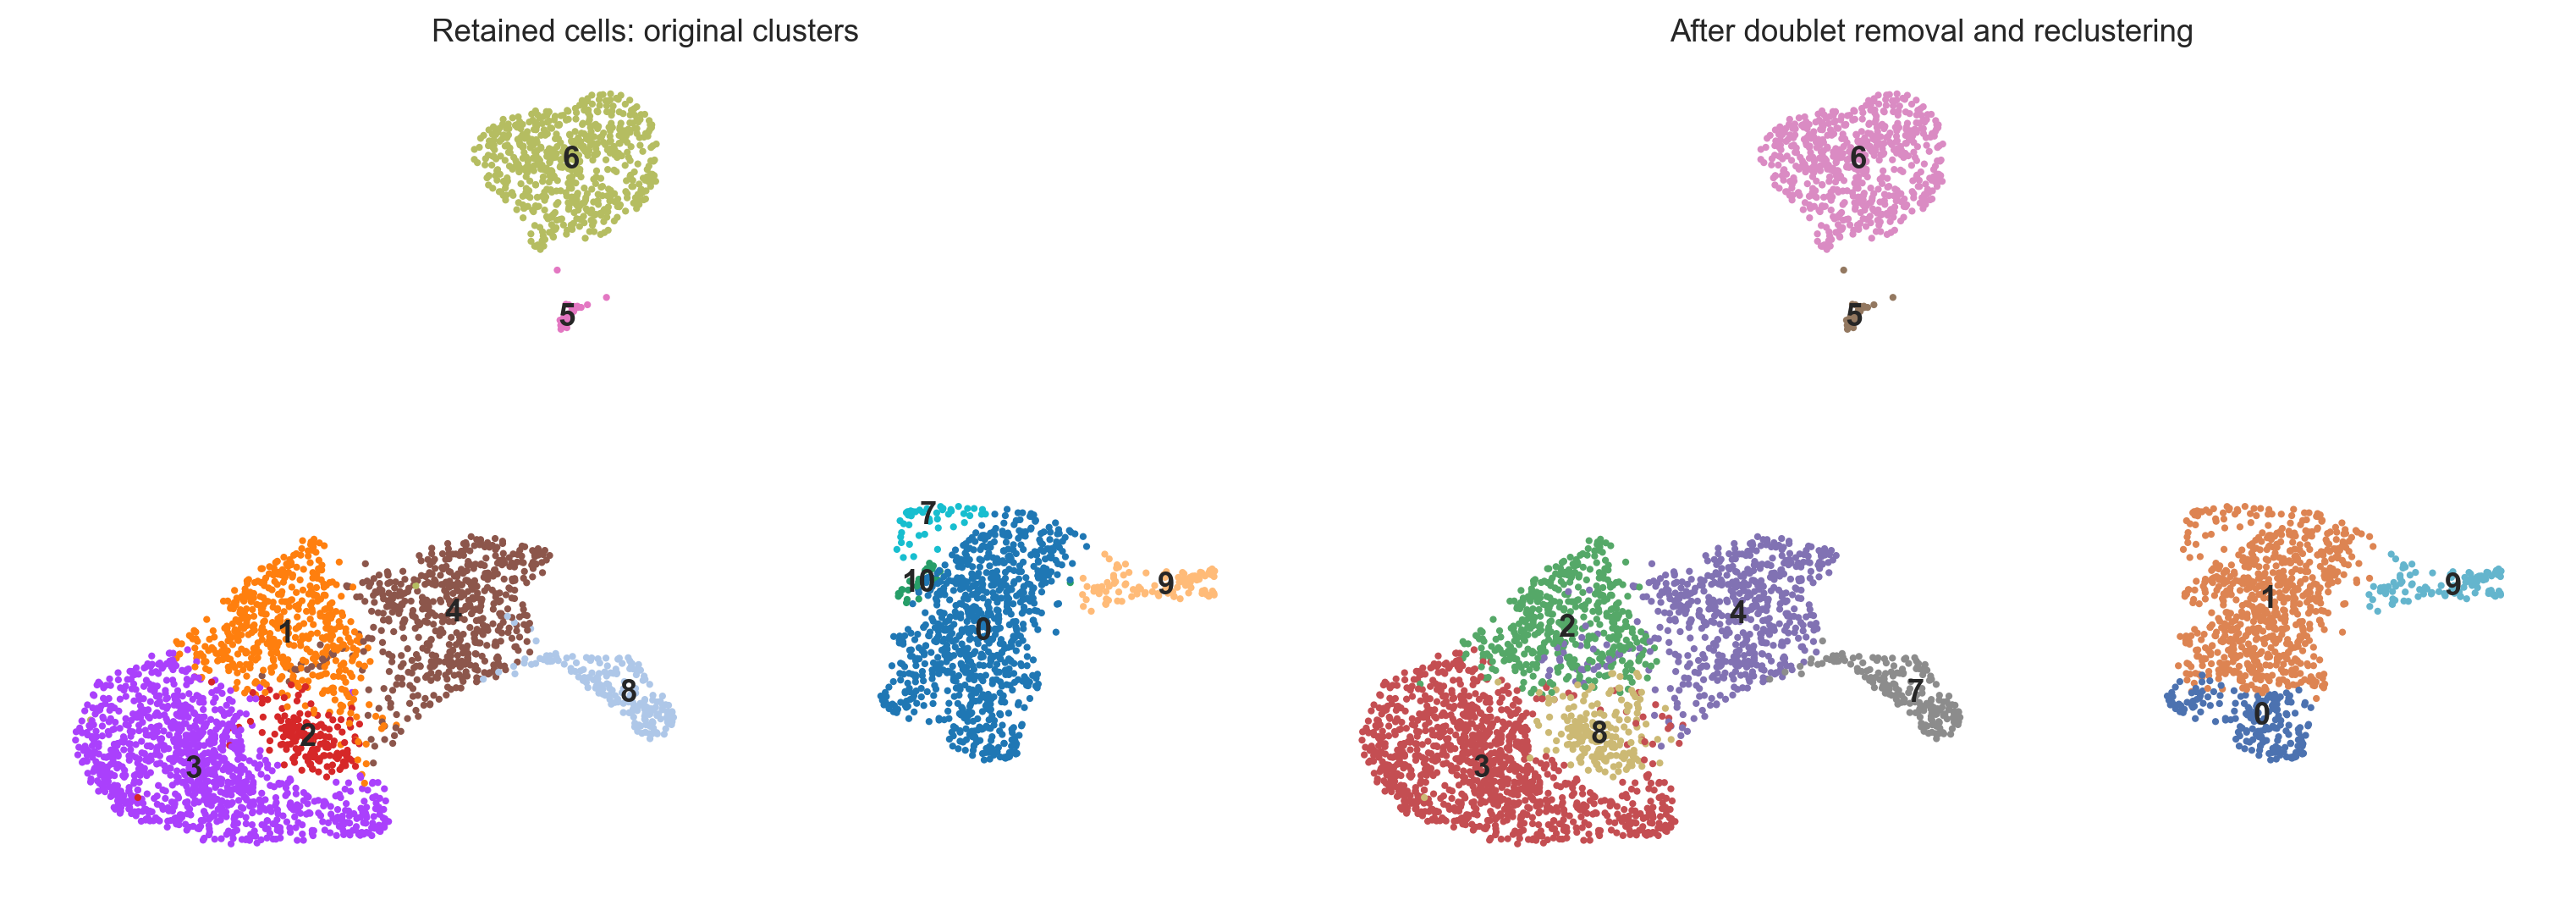

In [5]:
new_cluster_sizes = (
    singlet_adata.obs["leiden"].value_counts().sort_index().rename("cells").to_frame()
)
new_cluster_sizes["percent"] = 100 * new_cluster_sizes["cells"] / singlet_adata.n_obs
new_cluster_sizes.to_csv(TABLES / "pbmc4k_phase2b_singlet_cluster_sizes.csv")
display(new_cluster_sizes.style.format({"percent": "{:.1f}%"}))

cluster_mapping = pd.crosstab(
    singlet_adata.obs["original_leiden"].astype(str),
    singlet_adata.obs["leiden"].astype(str),
    rownames=["original_leiden"],
    colnames=["singlet_leiden"],
)
cluster_mapping.to_csv(TABLES / "pbmc4k_phase2b_original_to_singlet_cluster_mapping.csv")
display(cluster_mapping)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc.pl.umap(
    singlet_adata,
    color="original_leiden",
    legend_loc="on data",
    title="Retained cells: original clusters",
    ax=axes[0],
    show=False,
)
sc.pl.umap(
    singlet_adata,
    color="leiden",
    legend_loc="on data",
    title="After doublet removal and reclustering",
    ax=axes[1],
    show=False,
)
plt.tight_layout()
plt.savefig(FIGURES / "pbmc4k_phase2b_before_after_leiden_umap.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Recheck the same PBMC marker panel

This dictionary is copied unchanged from the PBMC3k marker-discovery notebook and PBMC4k Notebook 02.

    using 'X_pca' with n_pcs = 50


Storing dendrogram info using `.uns['dendrogram_leiden']`


categories: 0, 1, 2, etc.
var_group_labels: Naive/helper T, Cytotoxic T, NK, etc.


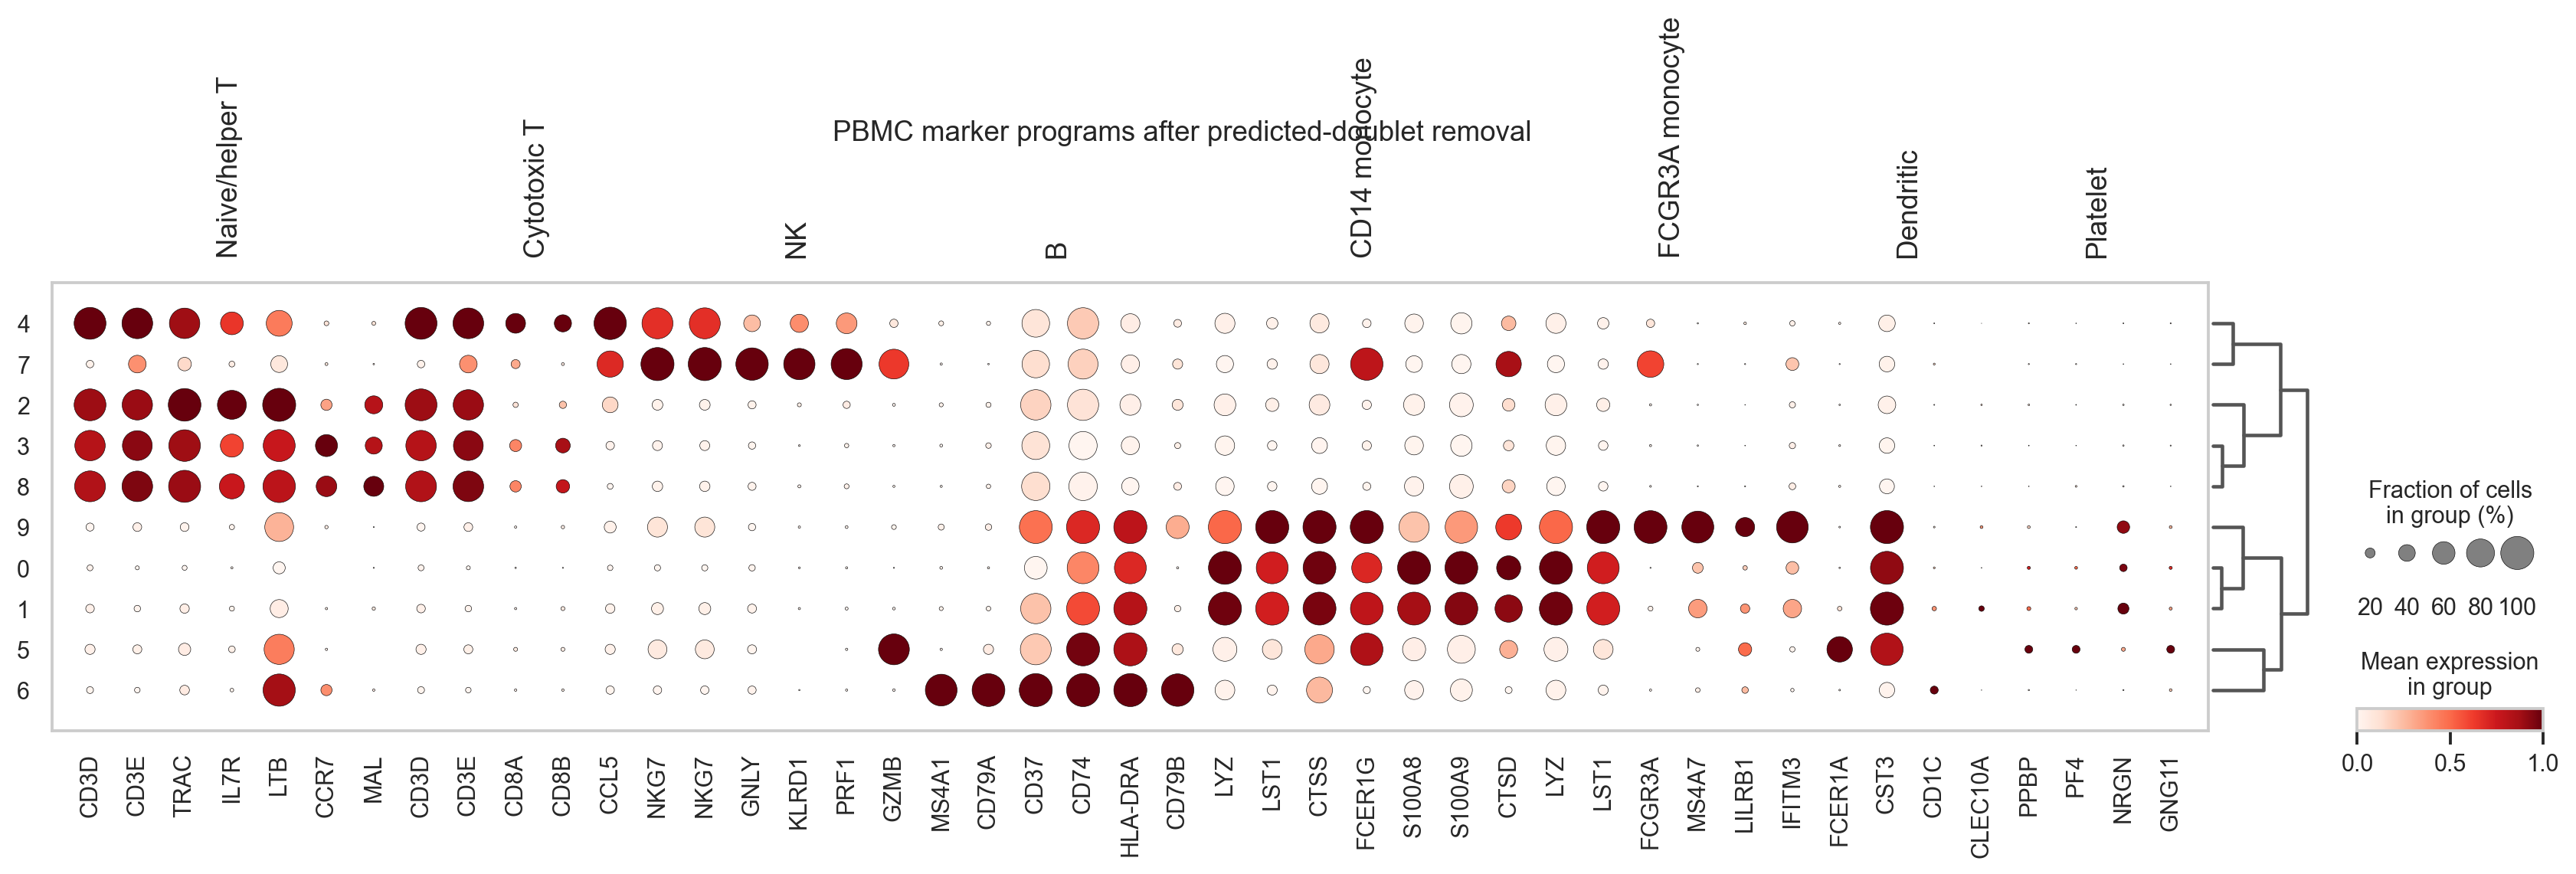

In [6]:
pbmc_marker_panel = {
    "Naive/helper T": ["CD3D", "CD3E", "TRAC", "IL7R", "LTB", "CCR7", "MAL"],
    "Cytotoxic T": ["CD3D", "CD3E", "CD8A", "CD8B", "CCL5", "NKG7"],
    "NK": ["NKG7", "GNLY", "KLRD1", "PRF1", "GZMB"],
    "B": ["MS4A1", "CD79A", "CD37", "CD74", "HLA-DRA", "CD79B"],
    "CD14 monocyte": ["LYZ", "LST1", "CTSS", "FCER1G", "S100A8", "S100A9", "CTSD"],
    "FCGR3A monocyte": ["LYZ", "LST1", "FCGR3A", "MS4A7", "LILRB1", "IFITM3"],
    "Dendritic": ["FCER1A", "CST3", "CD1C", "CLEC10A"],
    "Platelet": ["PPBP", "PF4", "NRGN", "GNG11"],
}
raw_genes = set(singlet_adata.raw.var_names)
available_pbmc_markers = {
    cell_type: [gene for gene in genes if gene in raw_genes]
    for cell_type, genes in pbmc_marker_panel.items()
}
available_pbmc_markers = {
    cell_type: genes for cell_type, genes in available_pbmc_markers.items() if genes
}

sc.pl.dotplot(
    singlet_adata,
    available_pbmc_markers,
    groupby="leiden",
    use_raw=True,
    standard_scale="var",
    dendrogram=True,
    title="PBMC marker programs after predicted-doublet removal",
    show=False,
)
plt.savefig(FIGURES / "pbmc4k_phase2b_singlet_marker_dotplot.png", dpi=160, bbox_inches="tight")
plt.show()

## 6. Recalculate data-derived marker genes

ranking genes


    finished (0:00:01)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,RP11-1143G9.4,20.228201,4.924306,5.528368e-91,9.044964e-87,0.978723,0.256404
1,0,S100A8,20.157127,5.362037,2.330227e-90,1.906242e-86,1.000000,0.583059
2,0,LYZ,19.412848,5.131172,6.010241e-84,3.277785e-80,0.994681,0.608420
3,0,FTL,19.285191,2.713250,7.152518e-83,2.925559e-79,1.000000,0.995181
4,0,S100A9,19.194244,4.919293,4.134462e-82,1.352879e-78,0.989362,0.663454
...,...,...,...,...,...,...,...,...
147254,9,PSAP,16.149195,3.502439,1.150555e-58,3.137373e-55,1.000000,0.578882
147255,9,FTH1,16.118090,2.473231,1.904041e-58,4.450288e-55,1.000000,0.991056
147256,9,SERPINA1,16.047302,4.277987,5.970403e-58,1.221022e-54,1.000000,0.232298
147257,9,FCER1G,15.923587,4.126081,4.347245e-57,7.902809e-54,1.000000,0.392298


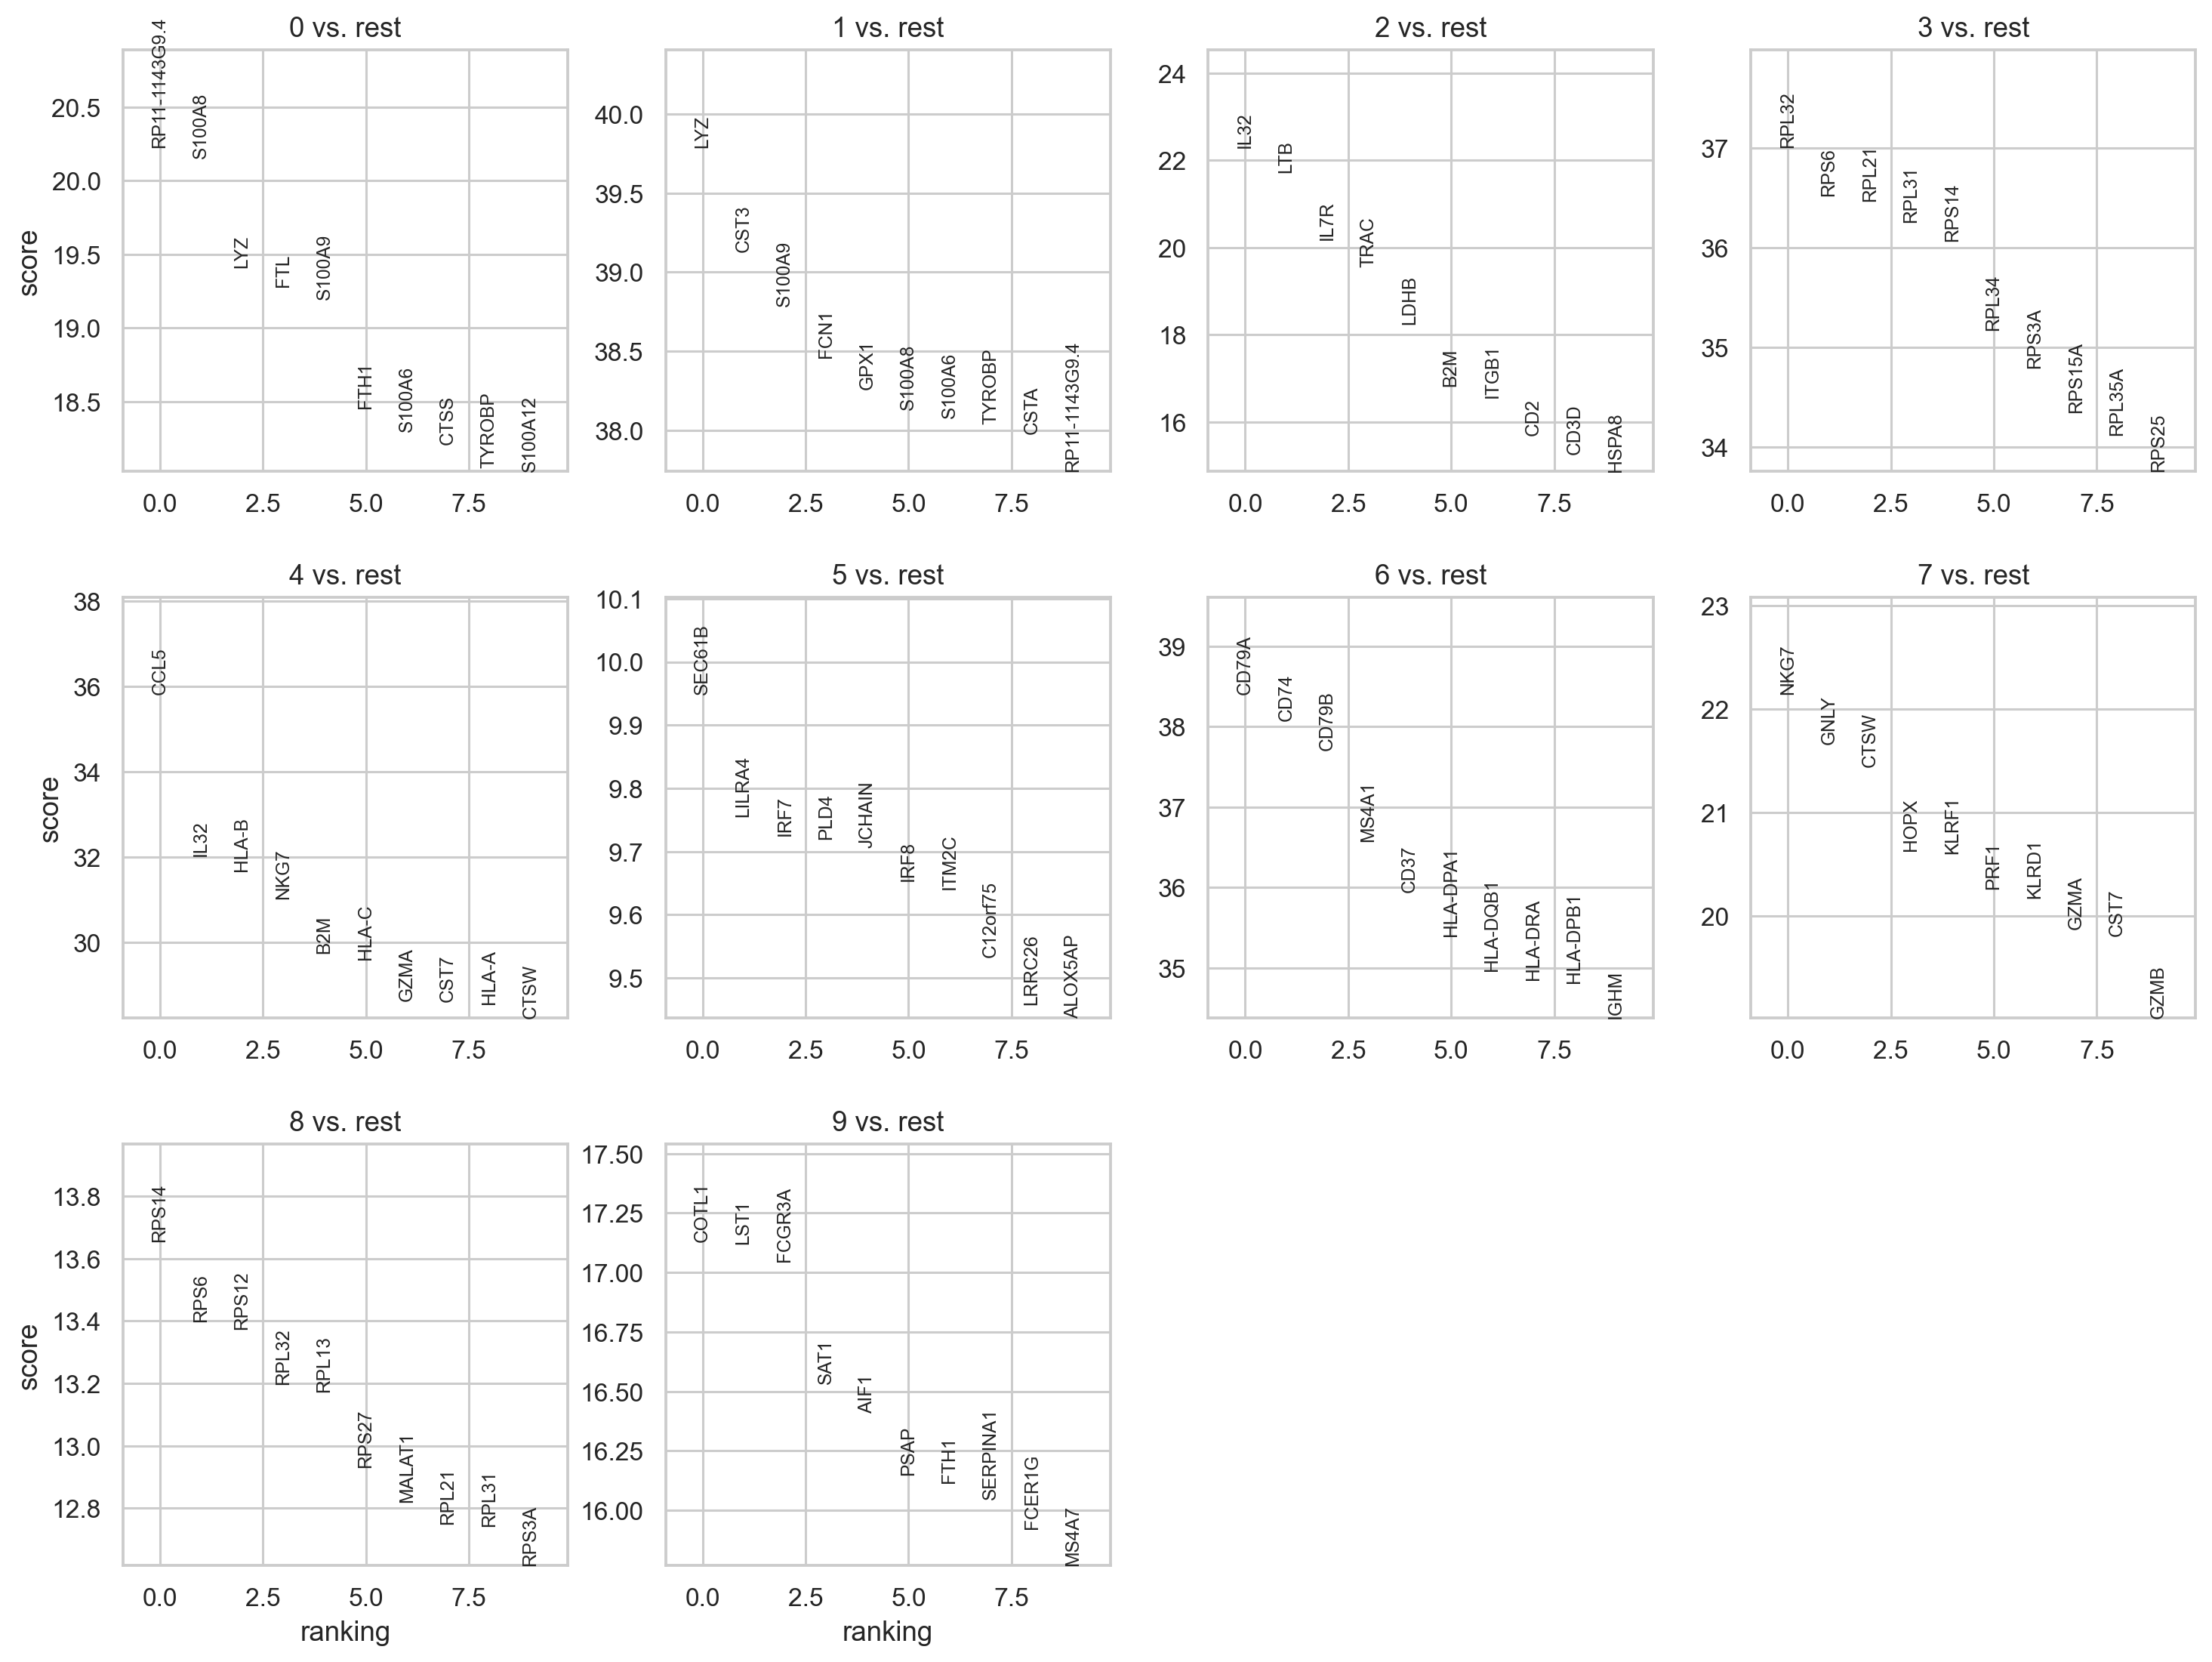

In [7]:
RANK_KEY = "rank_genes_groups_leiden_singlets"
sc.tl.rank_genes_groups(
    singlet_adata,
    groupby="leiden",
    method="wilcoxon",
    reference="rest",
    use_raw=True,
    pts=True,
    corr_method="benjamini-hochberg",
    key_added=RANK_KEY,
)

all_markers = sc.get.rank_genes_groups_df(singlet_adata, group=None, key=RANK_KEY)
all_markers["group"] = all_markers["group"].astype(str)
all_markers.to_csv(TABLES / "pbmc4k_phase2b_singlet_all_marker_statistics.csv", index=False)
top_markers = all_markers.groupby("group", observed=True).head(N_MARKERS_TO_DISPLAY)
top_markers.to_csv(TABLES / "pbmc4k_phase2b_singlet_top10_markers_per_cluster.csv", index=False)
display(top_markers)

sc.pl.rank_genes_groups(
    singlet_adata,
    key=RANK_KEY,
    n_genes=N_MARKERS_TO_DISPLAY,
    sharey=False,
    show=False,
)
plt.savefig(FIGURES / "pbmc4k_phase2b_singlet_ranked_markers.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Save the singlet-only clustered object

No final biological cell-type labels are assigned automatically.

In [8]:
singlet_adata.uns["doublet_filtering"] = {
    "source_object": str(VALIDATED_INPUT),
    "decision_column": "predicted_doublet",
    "starting_cells": int(phase1.n_obs),
    "removed_cells": int((~keep_mask).sum()),
    "retained_cells": int(singlet_adata.n_obs),
    "method": "pre-QC Scrublet decisions from PBMC4k Notebook 02",
}
singlet_adata.uns["phase2b_reclustering"] = {
    "random_state": RANDOM_STATE,
    "pca_components_used": pcs_used,
    "nearest_neighbors": N_NEIGHBORS,
    "leiden_resolution": LEIDEN_RESOLUTION,
    "observed_clusters": int(singlet_adata.obs["leiden"].nunique()),
    "final_cell_types_assigned": False,
}
singlet_adata.write_h5ad(OUTPUT, compression="gzip")

final_summary = pd.Series(
    {
        "starting QC-passing cells": phase1.n_obs,
        "predicted doublets removed": int((~keep_mask).sum()),
        "singlets retained": singlet_adata.n_obs,
        "PCA features": singlet_adata.n_vars,
        "full normalized genes in raw": singlet_adata.raw.n_vars,
        "Leiden clusters after reclustering": singlet_adata.obs["leiden"].nunique(),
        "output": str(OUTPUT),
    },
    name="PBMC4k Phase 2b result",
)
display(final_summary.to_frame())
print(f"Saved {OUTPUT.name} ({OUTPUT.stat().st_size / 1024**2:.1f} MB)")

,PBMC4k Phase 2b result
starting QC-passing cells,4169
predicted doublets removed,38
singlets retained,4131
PCA features,2000
full normalized genes in raw,16361
Leiden clusters after reclustering,10
output,/Users/Ema/Desktop/cosmos/26-the-backpropagato...


Saved pbmc4k_phase2_singlets_clustered.h5ad (63.3 MB)
